# Spatial Intelligence — Request 2
## What strategy should the public-health team consider across the territory?

You are a **remote consultant on spatial intelligence**. A public-health client is monitoring COVID-19 fatality rates across Peruvian provinces.

A choropleth map shows where fatality is high and low, but the client needs more than a descriptive map. It wants to distinguish different spatial situations:

- places already embedded in high-fatality environments;
- places with unusually high fatality despite safer surroundings;
- places that are currently safer but surrounded by high-fatality areas;
- places embedded in comparatively low-fatality environments.

The central question is:

> **What different kinds of attention may be warranted across the territory given the spatial pattern of fatality?**

We use spatial weights, spatial lag, global Moran's I, and Local Indicators of Spatial Association (LISA).

LISA does **not** prove contagion, causal spillovers, or future increases in fatality. It identifies local spatial patterns that can support further public-health investigation.

## 1. Getting ready

We use:

- **GeoPandas** for the spatial data;
- **libpysal** for neighborhood relationships;
- **esda** for Moran's I and LISA;
- **Matplotlib** for maps.

In [1]:
# !pip install -q pysal mapclassify

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.graph import Graph
import esda

## 2. Load the provincial COVID data

In [2]:
peru_data_url = (
    "https://github.com/Magallanes-at-UTDT/"
    "dataviz_2026/raw/main/mapaProvCovid.gpkg"
)

peru_covid = gpd.read_file(
    peru_data_url
)

print(peru_covid.crs)
peru_covid.head()

EPSG:24892


,DEPARTAMEN,PROVINCIA,PROV2,fallecidos_2020,positivos_2020,fallecidos_2021,positivos_2021,areaKm2,geometry
0,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,61.0,2166.0,191.0,4647.0,2906.932019,"MULTIPOLYGON (((529198.782 1433129.81, 529341...."
1,AMAZONAS,BAGUA,BAGUA,268.0,8037.0,153.0,3367.0,5793.966120,"MULTIPOLYGON (((429663.307 1591315.622, 429781..."
2,AMAZONAS,BONGARA,BONGARA,25.0,387.0,43.0,972.0,2832.855064,"MULTIPOLYGON (((528780.398 1521937.017, 529221..."
3,AMAZONAS,CONDORCANQUI,CONDORCANQUI,78.0,3465.0,26.0,551.0,17864.533565,"MULTIPOLYGON (((518879.106 1759683.135, 518744..."
4,AMAZONAS,LUYA,LUYA,20.0,452.0,63.0,1085.0,3306.793461,"MULTIPOLYGON (((484443.99 1437380.839, 484457...."


For a compact workshop example, we keep Lima, Callao, and neighboring departments used in the original teaching notebook.

In [3]:
study_area = peru_covid[
    peru_covid["DEPARTAMEN"]
    .str.startswith(
        (
            "LIMA",
            "CALL",
            "JUN",
            "ICA",
            "ANCA",
            "HUAN",
            "PASC"
        )
    )
].copy()

study_area = (
    study_area
    .set_index("PROVINCIA")
)

print(
    "Provinces in study area:",
    len(study_area)
)

Provinces in study area: 66


## 3. Construct the outcome: 2021 fatality rate

The rate is calculated as:

\[
	ext{fatality rate}
=
rac{	ext{deaths}}{	ext{positive cases}}
\]

The analysis concerns this observed rate, not infection risk.

In [4]:
study_area["fatality_2021"] = (
    study_area["fallecidos_2021"]
    / study_area["positivos_2021"]
)

study_area["fatality_2021"].describe()

count    66.000000
mean      0.112544
std       0.067245
min       0.020237
25%       0.072818
50%       0.094810
75%       0.126784
max       0.380952
Name: fatality_2021, dtype: float64

## 4. Start with the choropleth

This tells us **where values are high or low**, but it does not yet tell us whether those values form spatial patterns.

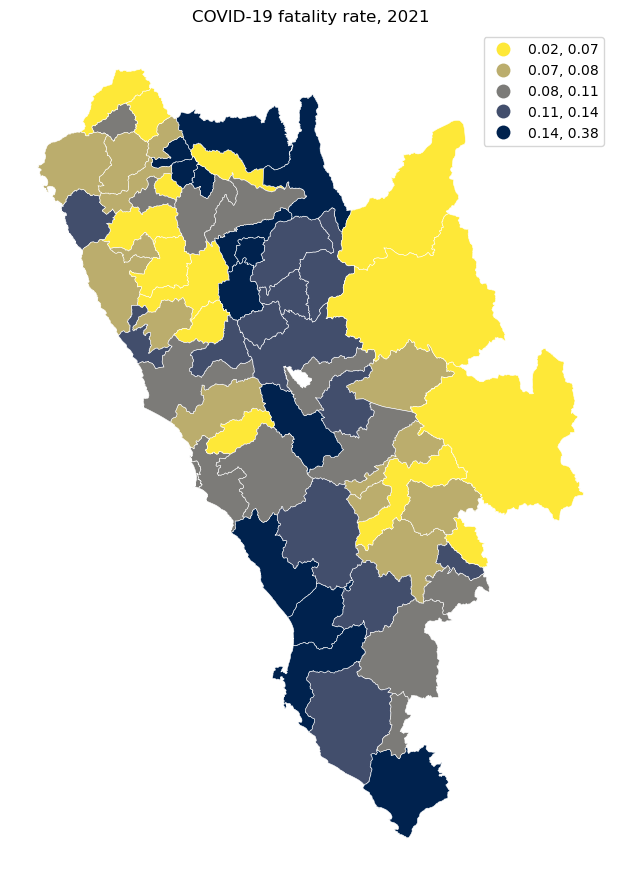

In [5]:
ax = study_area.plot(
    column="fatality_2021",
    scheme="quantiles",
    cmap="cividis_r",
    legend=True,
    figsize=(10, 11),
    edgecolor="white",
    linewidth=0.4
)

ax.set_title(
    "COVID-19 fatality rate, 2021"
)

ax.set_axis_off()
plt.show()

# Decision 1 — Who counts as a neighbor?

Spatial dependence cannot be studied until we define **neighborhood**.

We begin with **rook contiguity**:

> Two provinces are neighbors when they share a boundary segment.

This is an analytical assumption. Other definitions can produce different results.

In [6]:
rook = Graph.build_contiguity(
    study_area,
    rook=True
)

rook_r = rook.transform("r")

rook.explore(
    gdf=study_area,
    node_kws=dict(color="red"),
    edge_kws=dict(
        alpha=0.4,
        color="blue"
    ),
    zoom_start=7
)

## 5. How are my neighbors doing?

The **spatial lag** is the weighted average of the outcome among a province's neighbors.

It lets us compare:

- the province's own fatality rate; and
- the fatality environment surrounding it.

In [7]:
study_area["fatality_lag"] = (
    rook_r.lag(
        study_area["fatality_2021"]
    )
)

study_area[
    [
        "fatality_2021",
        "fatality_lag"
    ]
].head()

,fatality_2021,fatality_lag
PROVINCIA,,
HUARAZ,0.054360,0.085313
AIJA,0.080321,0.064023
ANTONIO RAIMONDI,0.201613,0.121286
ASUNCION,0.052288,0.116851
BOLOGNESI,0.056673,0.104207


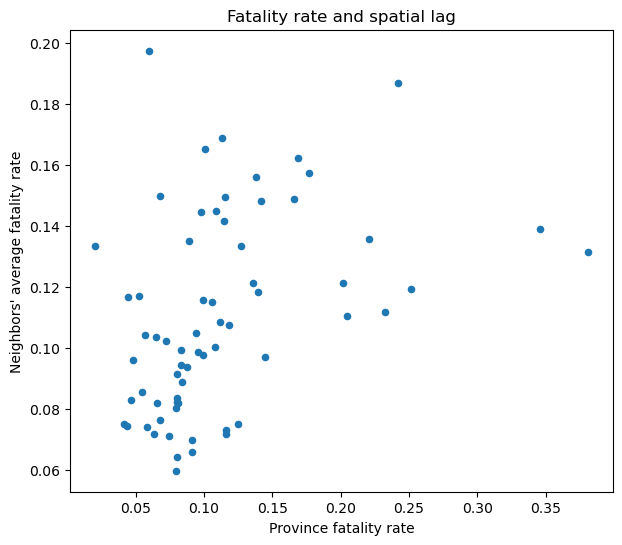

In [8]:
study_area.plot.scatter(
    x="fatality_2021",
    y="fatality_lag",
    figsize=(7, 6)
)

plt.xlabel("Province fatality rate")
plt.ylabel("Neighbors' average fatality rate")
plt.title("Fatality rate and spatial lag")
plt.show()

# Decision 2 — Is there global spatial dependence?

Global Moran's \(I\) asks whether similar values tend to be spatially close across the study area.

A permutation-based \(p\)-value evaluates whether the observed pattern is unusual under spatial randomness.

In [9]:
moran_global = esda.Moran(
    study_area["fatality_2021"],
    rook_r
)

global_result = pd.DataFrame([{
    "Moran I": moran_global.I,
    "Permutation p-value":
        moran_global.p_sim
}])

global_result

,Moran I,Permutation p-value
0,0.190943,0.007


A significant positive Moran's \(I\) would support the idea that high and low fatality values are spatially clustered. It does not identify *where* those clusters occur.

For local strategy we therefore move to LISA.

# Decision 3 — Identify local spatial situations with LISA

Local Moran's I classifies significant local patterns into four familiar configurations:

| Pattern | Local value | Neighbor values | Spatial-intelligence interpretation |
|---|---|---|---|
| **High–High (HH)** | High | High | High-fatality area inside a high-fatality environment |
| **High–Low (HL)** | High | Low | High-fatality spatial outlier |
| **Low–High (LH)** | Low | High | Lower-fatality area surrounded by higher-fatality neighbors |
| **Low–Low (LL)** | Low | Low | Lower-fatality area inside a lower-fatality environment |

These categories are patterns, not causes.

In [10]:
lisa_rook = esda.Moran_Local(
    study_area["fatality_2021"],
    rook_r,
    permutations=999,
    seed=123
)

study_area["LISA"] = (
    lisa_rook.get_cluster_labels(
        crit_value=0.05
    )
)

study_area["LISA"].value_counts()

LISA
Insignificant    59
Low-Low           4
High-High         2
Low-High          1
Name: count, dtype: int64

## 6. Translate spatial patterns into attention types

The consultant does not prescribe a medical intervention. Instead, the spatial analysis organizes the territory into different **attention types** for the public-health team.

- **HH — Priority intervention:** already high fatality in a high-fatality environment.
- **HL — Local investigation:** unusually high fatality relative to surrounding provinces.
- **LH — Early warning / prevention:** currently lower fatality but surrounded by high-fatality neighbors.
- **LL — Preserve and monitor:** comparatively favorable local and neighboring situation.
- **Insignificant — Routine monitoring:** no statistically significant local pattern at the selected threshold.

In [11]:
attention = {
    "High-High": "Priority intervention",
    "High-Low": "Local investigation",
    "Low-High": "Early warning / prevention",
    "Low-Low": "Preserve and monitor",
    "Insignificant": "Routine monitoring"
}

study_area["Attention type"] = (
    study_area["LISA"]
    .map(attention)
)

study_area[
    [
        "fatality_2021",
        "fatality_lag",
        "LISA",
        "Attention type"
    ]
].sort_values(
    ["LISA", "fatality_2021"],
    ascending=[True, False]
)

,fatality_2021,fatality_lag,LISA,Attention type
PROVINCIA,,,,
CHINCHA,0.242023,0.186887,High-High,Priority intervention
HUANUCO,0.112911,0.168857,High-High,Priority intervention
MARAÑON,0.380952,0.131263,Insignificant,Routine monitoring
CAÑETE,0.345932,0.138960,Insignificant,Routine monitoring
NAZCA,0.251208,0.119188,Insignificant,Routine monitoring
...,...,...,...,...
HUACAYBAMBA,0.060060,0.197464,Low-High,Early warning / prevention
CORONGO,0.090909,0.065673,Low-Low,Preserve and monitor
TAYACAJA,0.079177,0.059604,Low-Low,Preserve and monitor


## 7. Map the local spatial patterns

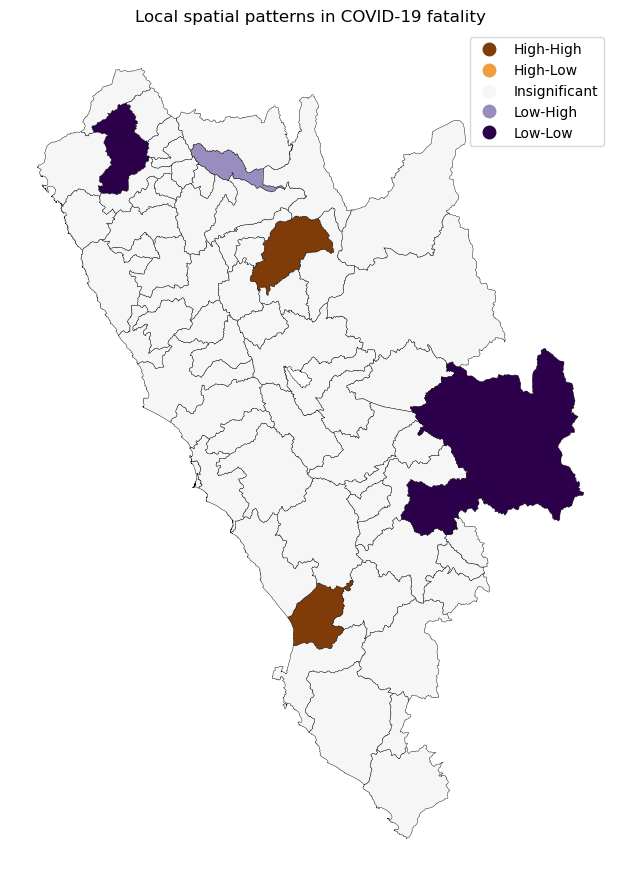

In [16]:
lisa_order = [
    "High-High",
    "High-Low",
    "Insignificant",
    "Low-High",
    "Low-Low"
]

study_area["LISA"] = pd.Categorical(
    study_area["LISA"],
    categories=lisa_order,
    ordered=True
)

ax = study_area.plot(
    column="LISA",
    categorical=True,
    cmap="PuOr",
    legend=True,
    figsize=(10, 11),
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "Local spatial patterns in COVID-19 fatality"
)

ax.set_axis_off()
plt.show()

## 8. Build the consultant's spatial-intelligence table

The table preserves the evidence behind the strategic interpretation:

- own fatality rate;
- neighbors' average fatality;
- LISA pattern;
- attention type.

In [18]:
strategy_table = (
    study_area[
        [
            "DEPARTAMEN",
            "fatality_2021",
            "fatality_lag",
            "LISA",
            "Attention type"
        ]
    ]
    .reset_index()
    .sort_values(
        ["LISA", "fatality_2021"],
        ascending=[True, False]
    )
)

strategy_table

,PROVINCIA,DEPARTAMEN,fatality_2021,fatality_lag,LISA,Attention type
40,CHINCHA,ICA,0.242023,0.186887,High-High,Priority intervention
28,HUANUCO,HUANUCO,0.112911,0.168857,High-High,Priority intervention
31,HUACAYBAMBA,HUANUCO,0.060060,0.197464,Low-High,Early warning / prevention
8,CORONGO,ANCASH,0.090909,0.065673,Low-Low,Preserve and monitor
27,TAYACAJA,HUANCAVELICA,0.079177,0.059604,Low-Low,Preserve and monitor
...,...,...,...,...,...,...
25,CHURCAMPA,HUANCAVELICA,0.047936,0.095894,Insignificant,Routine monitoring
65,OXAPAMPA,PASCO,0.046267,0.082978,Insignificant,Routine monitoring
55,CAJATAMBO,LIMA REGION,0.044164,0.116749,Insignificant,Routine monitoring
18,SIHUAS,ANCASH,0.043986,0.074330,Insignificant,Routine monitoring


# Decision 4 — Does the conclusion depend on how neighbors are defined?

Rook contiguity is not the only reasonable neighborhood definition.

We compare it with **3-nearest neighbors (KNN-3)**. If a province changes category, that is useful information: its classification is sensitive to the spatial assumptions.

In [19]:
knn3 = Graph.build_knn(
    study_area.representative_point(),
    k=3
)

knn3_r = knn3.transform("r")

lisa_knn3 = esda.Moran_Local(
    study_area["fatality_2021"],
    knn3_r,
    permutations=999,
    seed=123
)

study_area["LISA_KNN3"] = (
    lisa_knn3.get_cluster_labels(
        crit_value=0.05
    )
)

study_area["Same classification"] = (
    study_area["LISA"].astype(str)
    == study_area["LISA_KNN3"]
)

sensitivity = (
    study_area[
        [
            "fatality_2021",
            "LISA",
            "LISA_KNN3",
            "Same classification"
        ]
    ]
    .reset_index()
)

sensitivity

,PROVINCIA,fatality_2021,LISA,LISA_KNN3,Same classification
0,HUARAZ,0.054360,Insignificant,Insignificant,True
1,AIJA,0.080321,Insignificant,Insignificant,True
2,ANTONIO RAIMONDI,0.201613,Insignificant,Insignificant,True
3,ASUNCION,0.052288,Insignificant,Insignificant,True
4,BOLOGNESI,0.056673,Insignificant,Insignificant,True
...,...,...,...,...,...
61,OYON,0.139842,Insignificant,Insignificant,True
62,YAUYOS,0.127315,Insignificant,Insignificant,True
63,PASCO,0.111639,Insignificant,Insignificant,True
64,DANIEL ALCIDES CARRION,0.115174,Insignificant,Insignificant,True


In [20]:
sensitivity[
    ~sensitivity["Same classification"]
]

,PROVINCIA,fatality_2021,LISA,LISA_KNN3,Same classification
5,CARHUAZ,0.091384,Insignificant,Low-Low,False
11,HUAYLAS,0.074604,Low-Low,Insignificant,False
16,RECUAY,0.058057,Insignificant,Low-Low,False
27,TAYACAJA,0.079177,Low-Low,Insignificant,False
28,HUANUCO,0.112911,High-High,Insignificant,False
49,SATIPO,0.041219,Low-Low,Insignificant,False


# How to read the output

The most important analytical distinction is not simply **high versus low fatality**.

Spatial context separates provinces that may require different kinds of follow-up:

- **HH:** high values are part of a broader high-value cluster;
- **HL:** high values appear locally unusual and deserve investigation;
- **LH:** current local values are lower, but the surrounding context is unfavorable;
- **LL:** both local and neighboring values are comparatively low.

The public-health team should combine these patterns with epidemiological information, health-system capacity, mobility, vaccination, demographics, data quality, and current trends.

> **Decision boundary:** LISA organizes spatial evidence. It does not prove transmission, predict future fatality, or prescribe a public-health intervention.

## Exercise

Focus on the **Low–High (LH)** provinces.

1. Which provinces are classified as LH under rook contiguity?
2. Do they remain LH under KNN-3?
3. Which additional epidemiological variables would you request before calling them an early-warning priority?
4. Would the same attention strategy make sense if the outcome were infection incidence rather than fatality?